# 04 - VAE Training on Correlation Matrices

This notebook trains a **Variational Autoencoder (VAE)** on correlation tensors saved in `data/processed/corr_windows_tensor_data_*.pt`.

Key design choice:
- **VAE input**: only elements from the **upper triangular** part of the correlation matrix
- **VAE output**: reconstruction of the same upper triangular part

This allows the model to learn a compact representation consistent with the symmetric structure of correlation matrices.

In [14]:
import random
from pathlib import Path
import sys
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import matplotlib.pyplot as plt

In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [16]:
MY_FILE_NAME = "corr_windows_tensor_data_00_20_w724_s10.pt"
if 'google.colab' in sys.modules:
    print("Ambiente rilevato: Google Colab")
    IS_COLAB = True
else:
    print("Ambiente rilevato: Locale (PC)")
    IS_COLAB = False


if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    processed_dir = Path("/content/drive/MyDrive/dataset_tesi")
else:
    project_root = Path.cwd().resolve().parent
    processed_dir = project_root / "data" / "processed"

selected_file = processed_dir / MY_FILE_NAME

if not selected_file.exists():
    raise FileNotFoundError(
        f"Errore: Il file '{MY_FILE_NAME}' non e stato trovato in: {processed_dir.absolute()}"
    )

print(f"File selezionato: {selected_file.name}")

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # numeber or None
MATRIX_END = None  # numeber or None, Example: 500 to use only the first 500 matrices
print(f"Matrix range: [{MATRIX_START}, {MATRIX_END})")

Ambiente rilevato: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File selezionato: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [17]:
data = torch.load(selected_file, map_location="cpu")

corr_tensor = data["corr_tensor"].float()
window_ranges = data.get("window_ranges", None)
timestamps = data.get("timestamps", None)
window_length = data.get("window_length", None)
stride = data.get("stride", None)
tickers = data.get("tickers", None)

orig_N, D, D2 = corr_tensor.shape
if D != D2:
    raise ValueError(f"Matrices are not square: {corr_tensor.shape}")

start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_N if MATRIX_END is None else int(MATRIX_END)
if not (0 <= start_idx < end_idx <= orig_N):
    raise ValueError(
        f"Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_N}"
    )

corr_tensor = corr_tensor[start_idx:end_idx]
if window_ranges is not None and len(window_ranges) == orig_N:
    window_ranges = window_ranges[start_idx:end_idx]

N, D, D2 = corr_tensor.shape
print(f"corr_tensor shape (selected range): {corr_tensor.shape}")
print(f"using matrices: [{start_idx}, {end_idx}) out of {orig_N}")
print(f"dtype: {corr_tensor.dtype}")
print(f"window_length: {window_length}, stride: {stride}")
print(f"#tickers: {len(tickers) if tickers is not None else 'N/A'}")

corr_tensor shape (selected range): torch.Size([412, 362, 362])
using matrices: [49, 461) out of 461
dtype: torch.float32
window_length: 724, stride: 10
#tickers: 362


In [18]:
# Upper triangular indices (excluding diagonal)
tri_u_idx = torch.triu_indices(row=D, col=D, offset=1)
print(f"Upper triangular indices shape: {tri_u_idx.shape}")
tri_size = tri_u_idx.shape[1]

# X contains only upper triangular elements for each matrix
X = corr_tensor[:, tri_u_idx[0], tri_u_idx[1]].contiguous()  # .contiguous() ensures the tensor is contiguous in memory, size (N, tri_size)
print(f"VAE input dimension (upper triangular): {tri_size}")
print(f"X shape: {X.shape}")

Upper triangular indices shape: torch.Size([2, 65341])
VAE input dimension (upper triangular): 65341
X shape: torch.Size([412, 65341])


In [19]:
# Main hyperparameters
RUN = "04"
BATCH_SIZE = 8
VAL_RATIO = 0.2
TEST_RATIO = 0.1
LATENT_DIM = 3
HIDDEN_DIMS = [4096, 2048, 1024]
BETA = 1
LEARNING_RATE = 1e-7
WEIGHT_DECAY = 1e-5
EPOCHS = 100

# Train/validation/test split
if VAL_RATIO + TEST_RATIO >= 1.0:
    raise ValueError("VAL_RATIO + TEST_RATIO must be < 1.0")

full_ds = TensorDataset(X)
n_total = len(full_ds)
test_size = int(n_total * TEST_RATIO)
val_size = int(n_total * VAL_RATIO)
train_size = n_total - val_size - test_size

train_ds, val_ds, test_ds = random_split(
    full_ds,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
 )

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train size: {train_size}")
print(f"Val size:   {val_size}")
print(f"Test size:  {test_size}")

Train size: 289
Val size:   82
Test size:  41


In [20]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.ReLU())
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.ReLU())
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [21]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction="mean")
    # Average KL divergence per batch
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, recon, kl


def run_epoch(model, loader, optimizer=None, beta=1.0, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_samples = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        bs = x_batch.size(0)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train): # Only compute gradients during training, equal to "with torch.no_grad()" when is_train is False
            x_hat, mu, logvar = model(x_batch)
            loss, recon, kl = vae_loss(x_hat, x_batch, mu, logvar, beta=beta)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * bs
        total_recon += recon.item() * bs
        total_kl += kl.item() * bs
        total_samples += bs

    return {
        "loss": total_loss / total_samples,
        "recon": total_recon / total_samples,
        "kl": total_kl / total_samples,
    }

In [22]:
input_dim = X.shape[1]
model = VAE(input_dim=input_dim, hidden_dims=HIDDEN_DIMS, latent_dim=LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
}

best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer=optimizer, beta=BETA, device=DEVICE)
    va = run_epoch(model, val_loader, optimizer=None, beta=BETA, device=DEVICE)

    history["train_loss"].append(tr["loss"])
    history["train_recon"].append(tr["recon"])
    history["train_kl"].append(tr["kl"])
    history["val_loss"].append(va["loss"])
    history["val_recon"].append(va["recon"])
    history["val_kl"].append(va["kl"])

    if va["loss"] < best_val:
        best_val = va["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train Loss {tr['loss']:.6f} (Recon {tr['recon']:.6f}, KL {tr['kl']:.6f}) | "
        f"Val Loss {va['loss']:.6f} (Recon {va['recon']:.6f}, KL {va['kl']:.6f})"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best weights with val_loss = {best_val:.6f}")

Epoch 001/100 | Train Loss 0.153079 (Recon 0.152937, KL 0.000142) | Val Loss 0.162099 (Recon 0.162089, KL 0.000010)
Epoch 002/100 | Train Loss 0.152517 (Recon 0.152511, KL 0.000006) | Val Loss 0.161767 (Recon 0.161764, KL 0.000003)
Epoch 003/100 | Train Loss 0.151961 (Recon 0.151958, KL 0.000003) | Val Loss 0.161363 (Recon 0.161361, KL 0.000002)
Epoch 004/100 | Train Loss 0.151665 (Recon 0.151662, KL 0.000002) | Val Loss 0.160750 (Recon 0.160748, KL 0.000002)
Epoch 005/100 | Train Loss 0.151173 (Recon 0.151171, KL 0.000001) | Val Loss 0.160400 (Recon 0.160399, KL 0.000001)
Epoch 006/100 | Train Loss 0.150738 (Recon 0.150737, KL 0.000001) | Val Loss 0.159925 (Recon 0.159924, KL 0.000001)
Epoch 007/100 | Train Loss 0.150247 (Recon 0.150246, KL 0.000001) | Val Loss 0.159462 (Recon 0.159462, KL 0.000001)
Epoch 008/100 | Train Loss 0.149845 (Recon 0.149844, KL 0.000001) | Val Loss 0.158889 (Recon 0.158889, KL 0.000001)
Epoch 009/100 | Train Loss 0.149391 (Recon 0.149390, KL 0.000001) | Val 

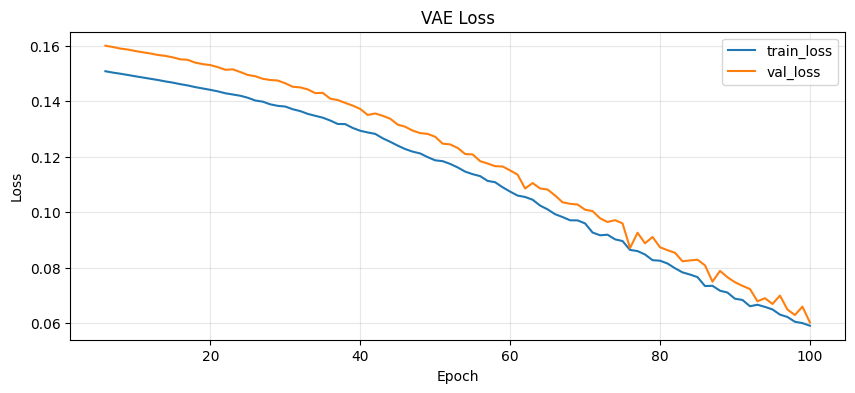

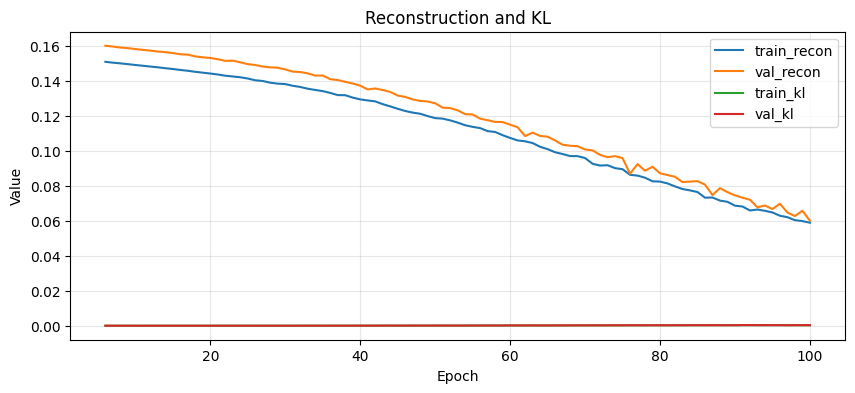

Plots saved in: /content/drive/MyDrive/best_models_tesi/results_w724_s10_RUN04


In [23]:
epochs = np.arange(1, EPOCHS + 1)

# Prepare output directory for saving plots
if IS_COLAB:
    base_save_dir = Path("/content/drive/MyDrive/best_models_tesi")
else:
    base_save_dir = project_root / "models"

folder_name = f"results_w{window_length}_s{stride}_RUN{RUN}"
run_dir = base_save_dir / folder_name
run_dir.mkdir(parents=True, exist_ok=True)

# First plot: VAE Loss
plt.figure(figsize=(10, 4))
plt.plot(epochs[5:], history["train_loss"][5:], label="train_loss")
plt.plot(epochs[5:], history["val_loss"][5:], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(run_dir / f"vae_loss_w{window_length}_s{stride}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

# Second plot: Reconstruction and KL
plt.figure(figsize=(10, 4))
plt.plot(epochs[5:], history["train_recon"][5:], label="train_recon")
plt.plot(epochs[5:], history["val_recon"][5:], label="val_recon")
plt.plot(epochs[5:], history["train_kl"][5:], label="train_kl")
plt.plot(epochs[5:], history["val_kl"][5:], label="val_kl")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Reconstruction and KL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(run_dir / f"recon_kl_w{window_length}_s{stride}_RUN{RUN}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plots saved in: {run_dir}")

--- Statistics for Sample [0] ---
Reconstruction MSE: 0.028562
Max Error: 0.360585
Min Error: -0.853654
Mean Absolute Error: 0.130683


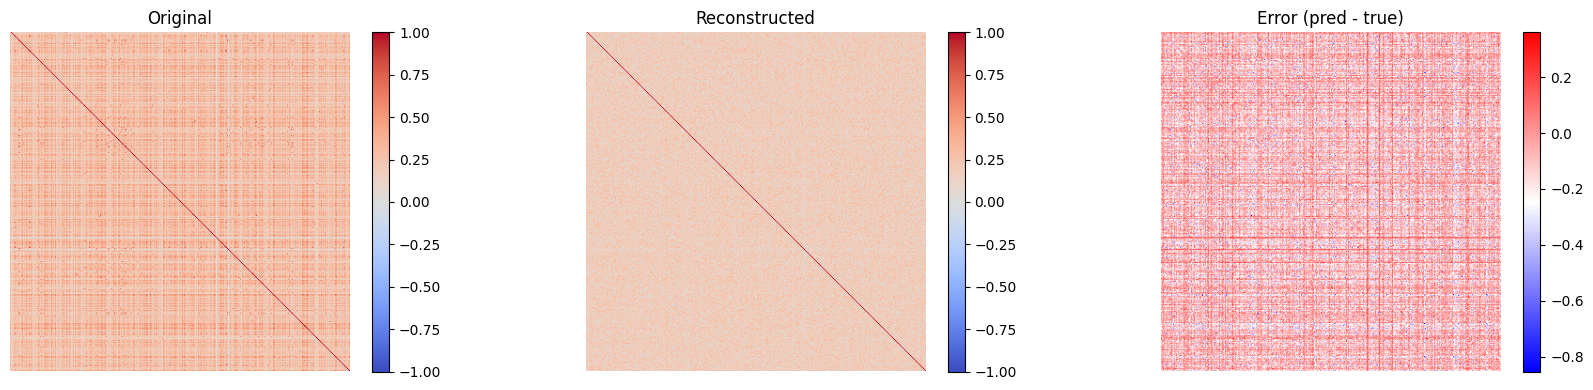

In [24]:
def upper_vec_to_full_corr(vec: torch.Tensor, tri_indices: torch.Tensor, dim: int) -> torch.Tensor:
    """Reconstruct a symmetric correlation matrix from an upper-triangular vector."""
    mat = torch.zeros((dim, dim), dtype=vec.dtype, device=vec.device)
    mat.fill_diagonal_(1.0)
    i, j = tri_indices[0], tri_indices[1]
    mat[i, j] = vec
    mat[j, i] = vec
    return mat

model.eval()
with torch.no_grad():
    sample_idx = 0
    x_true = X[sample_idx:sample_idx+1].to(DEVICE) # shape (1, tri_size)
    x_pred, _, _ = model(x_true) # shape (1, tri_size)

x_true_vec = x_true.squeeze(0).cpu() # shape (tri_size,)
x_pred_vec = x_pred.squeeze(0).cpu() # shape (tri_size,)

mse_sample = F.mse_loss(x_pred_vec, x_true_vec).item()
errors = x_pred_vec - x_true_vec
max_err = errors.max().item()
min_err = errors.min().item()
mean_abs_err = errors.abs().mean().item()

print(f"--- Statistics for Sample [{sample_idx}] ---")
print(f"Reconstruction MSE: {mse_sample:.6f}")
print(f"Max Error: {max_err:.6f}")
print(f"Min Error: {min_err:.6f}")
print(f"Mean Absolute Error: {mean_abs_err:.6f}")

true_mat = upper_vec_to_full_corr(x_true_vec, tri_u_idx, D)
pred_mat = upper_vec_to_full_corr(x_pred_vec, tri_u_idx, D)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
im0 = axes[0].imshow(true_mat.numpy(), vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Original")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(pred_mat.numpy(), vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Reconstructed")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow((pred_mat - true_mat).numpy(), cmap="bwr")
axes[2].set_title("Error (pred - true)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [25]:
model_path = run_dir / f"model_weights_w{window_length}_s{stride}_RUN{RUN}.pth"
metadata_path = run_dir / f"metadata_w{window_length}_s{stride}_RUN{RUN}.json"

torch.save(model.state_dict(), model_path)

metadata = {
    "run_name": folder_name,
    "input_dim": int(input_dim),
    "hidden_dims": HIDDEN_DIMS,
    "latent_dim": LATENT_DIM,
    "beta": float(BETA),
    "best_val_loss": float(best_val),
    "history": history,
    "selected_file": str(selected_file),
    "matrix_dim": int(D),
    "window_length": int(window_length),
    "stride": int(stride),
    "seed": int(SEED),
    "start_idx": int(start_idx),
    "end_idx": int(end_idx),
    "tickers": list(tickers) if tickers is not None else []
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"Run results saved in: {run_dir}")
print(f"  - Weights: {model_path.name}")
print(f"  - Metadata: {metadata_path.name}")

Run results saved in: /content/drive/MyDrive/best_models_tesi/results_w724_s10_RUN04
  - Weights: model_weights_w724_s10_RUN04.pth
  - Metadata: metadata_w724_s10_RUN04.json
